# 3. Pile-up Assessment (Script 03)

Now that we have a clean event file, we must check for event pile-up. This happens in bright sources when photons arrive so quickly that the detector registers two (or more) events as a single, higher-energy event. This distorts the spectrum.

The script `03_check_pileup.sh` uses the `epatplot` task to check for pile-up. This task creates a plot of event patterns (singles, doubles, etc.). In the absence of pile-up, the observed pattern distribution should match the expected distribution. If pile-up is present, the observed distribution will deviate from the expected, typically showing a deficit of single events (ratio < 1) and an excess of double events (ratio > 1) at higher energies.

### Script Configuration

The script contains a **USER CONFIGURATION** section at the top with the following variables:

| Variable | Description | Current Value |
|---|---|---|
| `SRC_RAWX_FILTER` | RAWX columns for the full source region | `RAWX in [27:47]` |
| `BKG_RAWX_FILTER` | RAWX columns for the background region | `RAWX in [1:3]` |
| `EPAT_PIMIN` | Lower energy bound for `epatplot` diagnostic (eV) | `500` |
| `EPAT_PIMAX` | Upper energy bound for `epatplot` diagnostic (eV) | `2000` |
| `RUN_EXCISION_TEST` | Whether to generate an excised plot | `yes` |
| `SRC_EXCISION_FILTER` | Central columns to remove for pile-up correction | `!(RAWX in [36:38])` |

### Workflow

1. Edit the **USER CONFIGURATION** in `03_check_pileup.sh`.
2. Run the script -- it creates the RAWX/RAWY image, `epatplot_FULL`, and (if enabled) `epatplot_EXCISED`.
3. Inspect the outputs below.
4. If pile-up persists, adjust the configuration and re-run.

## 3a. Setup

In [1]:
import os
import subprocess
from IPython.display import Image, display

# --- Environment ---
os.environ['PROJECT_ROOT'] = '/media/kyle/kyle_phd/Swift-j1858.6-0814'
os.environ['OBSID'] = '0865600201'

# --- Derived Paths ---
project_root = os.environ['PROJECT_ROOT']
obsid = os.environ['OBSID']

pn_dir = f"{project_root}/products/{obsid}/pn"
pu_dir = f"{pn_dir}/pile_up"

image_file_fits = f"{pn_dir}/pn_rawx_rawy_image.fits"
image_file_png  = f"{pn_dir}/pn_rawx_rawy_image.png"
full_plot_path    = f"{pu_dir}/epatplot_FULL.jpg"
excised_plot_path = f"{pu_dir}/epatplot_EXCISED.jpg"

print(f"Products dir : {pn_dir}")
print(f"Pile-up plots: {pu_dir}")

Products dir : /media/kyle/kyle_phd/Swift-j1858.6-0814/products/0865600201/pn
Pile-up plots: /media/kyle/kyle_phd/Swift-j1858.6-0814/products/0865600201/pn/pile_up


## 3b. Run Script

This single execution performs all steps:
1. Creates the RAWX/RAWY image for region inspection.
2. Filters source and background events.
3. Generates `epatplot_FULL` for the full source region.
4. If `RUN_EXCISION_TEST="yes"`, generates `epatplot_EXCISED` with the core columns removed.

> **Before running:** Ensure the USER CONFIGURATION in `03_check_pileup.sh` is set correctly.

In [2]:
!../scripts/03_check_pileup.sh > logs/03_check_pileup.log 2>&1
print("Done. Check logs/03_check_pileup.log for details.")

Done. Check logs/03_check_pileup.log for details.


## 3c. Inspect RAWX/RAWY Image

Open the RAWX/RAWY image in ds9 to identify the correct source and background RAWX columns. Use these to update `SRC_RAWX_FILTER` and `BKG_RAWX_FILTER` in the script if needed.

In [3]:
subprocess.Popen(['ds9', image_file_fits, '-zoom', 'to', 'fit'])
print(f"Launched ds9 with: {image_file_fits}")

Launched ds9 with: /media/kyle/kyle_phd/Swift-j1858.6-0814/products/0865600201/pn/pn_rawx_rawy_image.fits


RAWX-RAWY Image: /media/kyle/kyle_phd/Swift-j1858.6-0814/products/0865600201/pn/pn_rawx_rawy_image.png


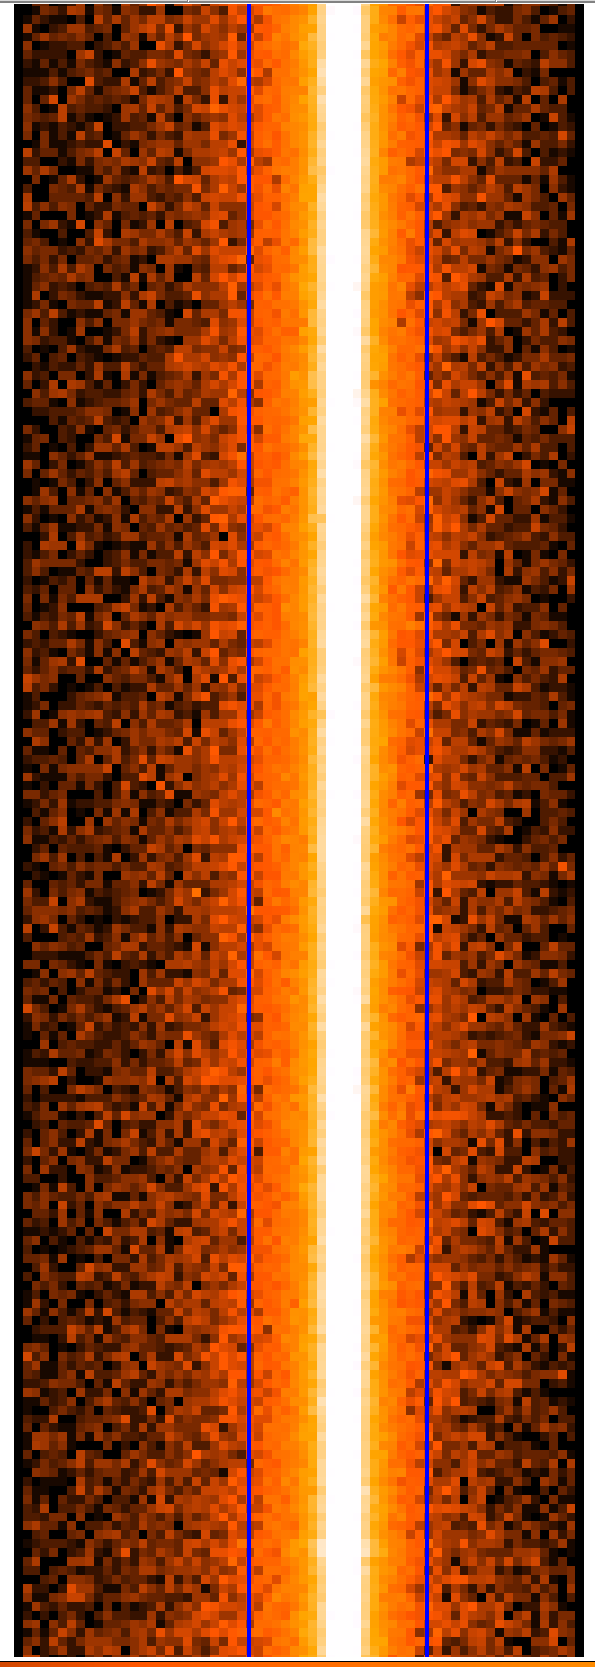

In [4]:
# Display the saved PNG screenshot (if available)
if os.path.exists(image_file_png):
    print(f"RAWX-RAWY Image: {image_file_png}")
    display(Image(filename=image_file_png, width=500))
else:
    print(f"No PNG screenshot found at {image_file_png}")
    print("Use the ds9 cell above to inspect the FITS image directly.")

**Region Selection:**
- Source region: `RAWX in [27:47]`
- Background region: `RAWX in [1:3]`

## 3d. Inspect epatplot Results

The `epatplot` output plots show the observed vs. expected event-pattern distributions. Look for:
- **No pile-up:** Observed histograms match the smooth model curves; singles/doubles ratios ~1.0.
- **Pile-up present:** Singles deficit (ratio < 1), doubles excess (ratio > 1), especially at higher energies.

FULL region epatplot: /media/kyle/kyle_phd/Swift-j1858.6-0814/products/0865600201/pn/pile_up/epatplot_FULL.jpg


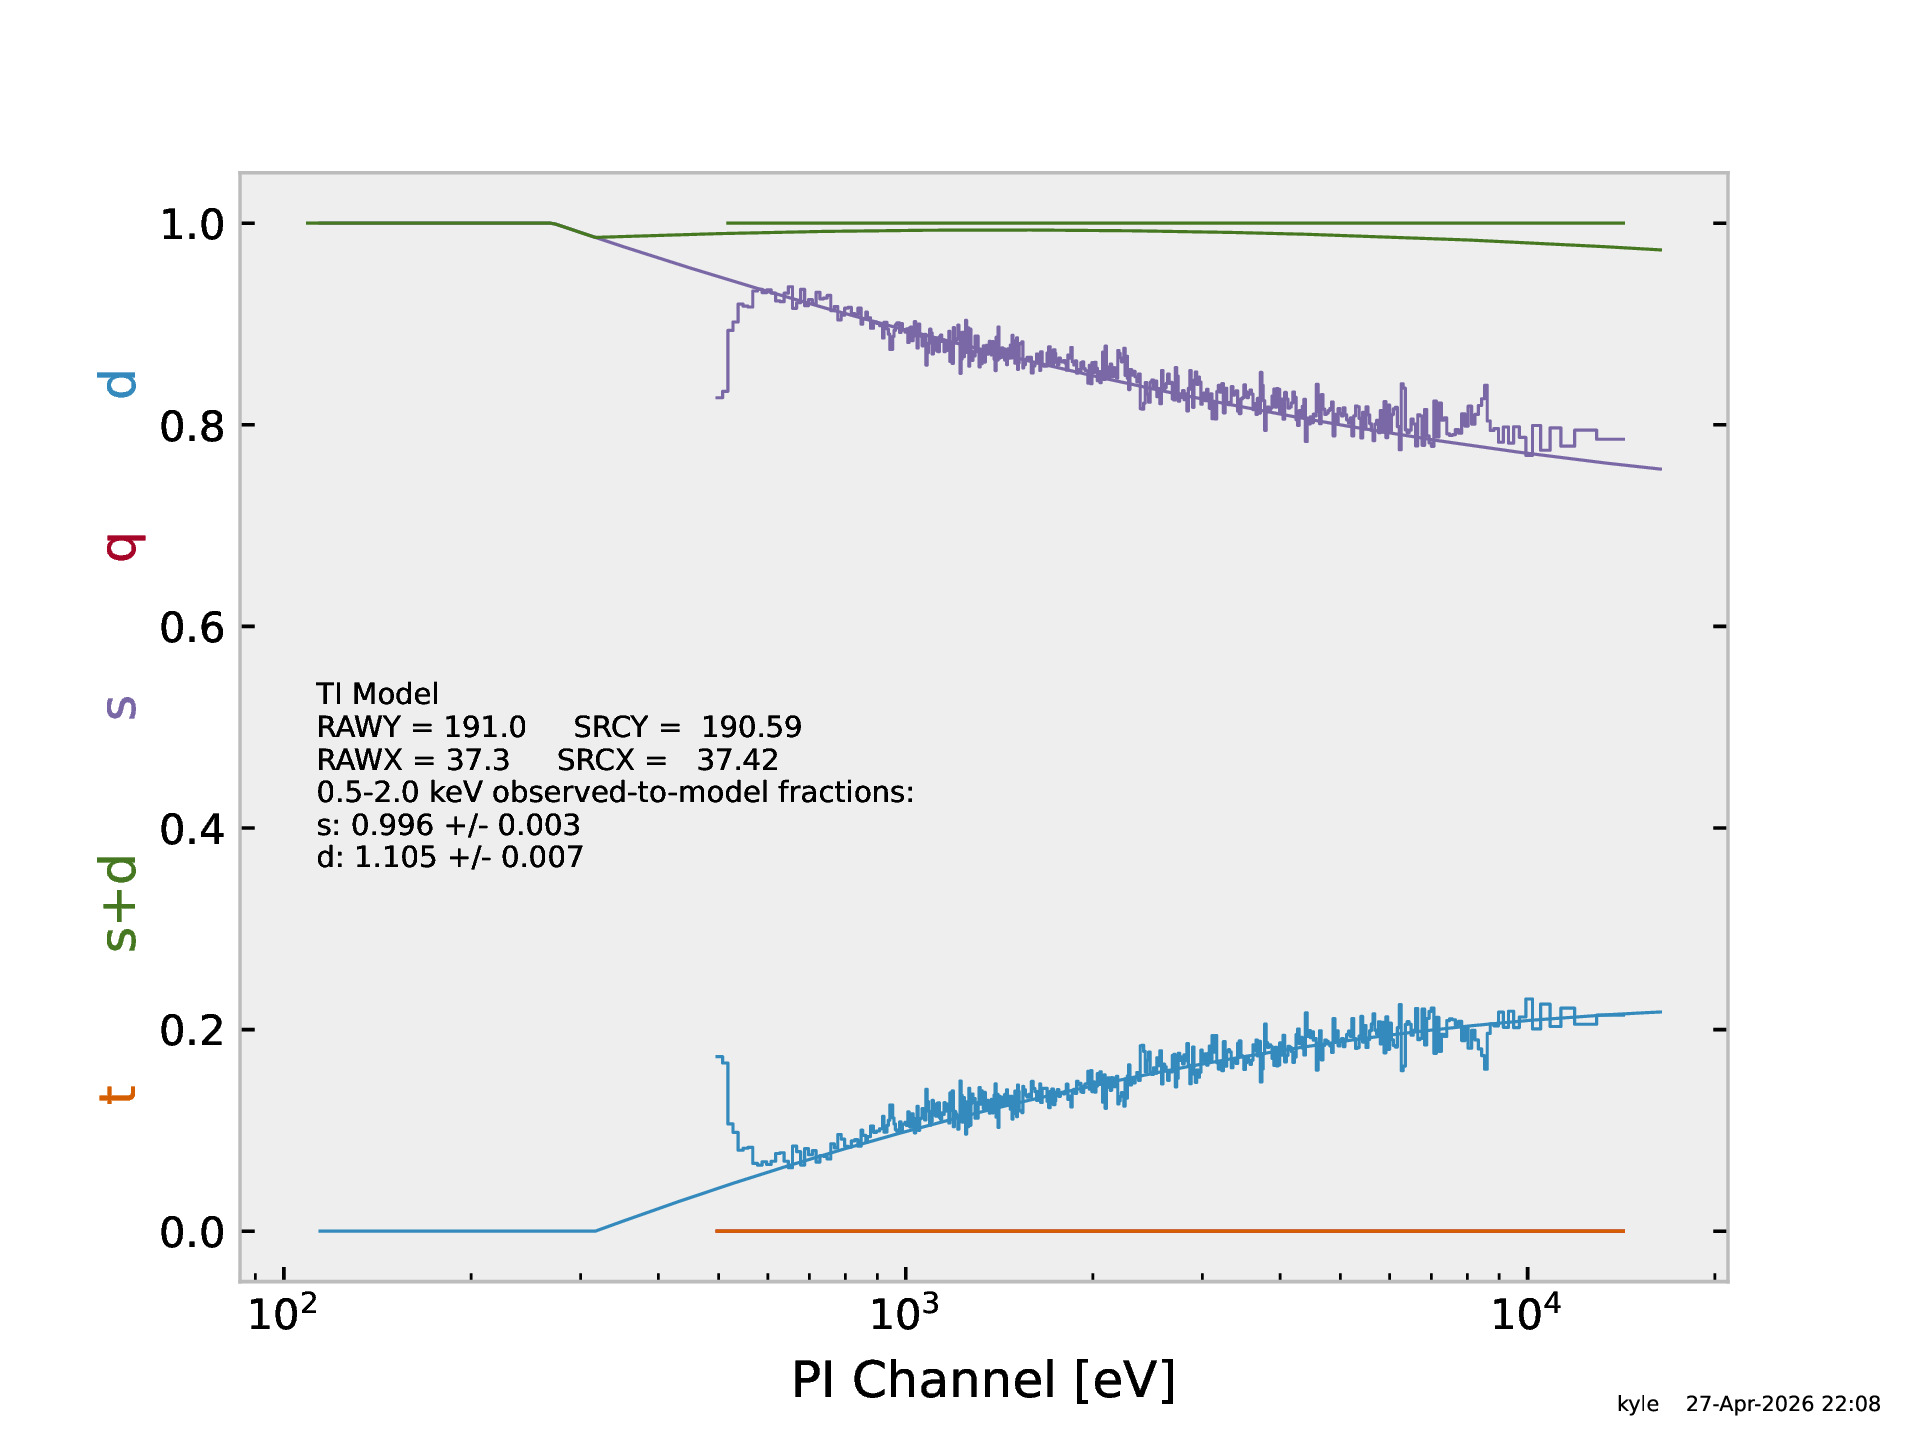

In [5]:
# --- Full Source Region ---
if os.path.exists(full_plot_path):
    print(f"FULL region epatplot: {full_plot_path}")
    display(Image(filename=full_plot_path, width=500))
else:
    print(f"ERROR: Full plot not found at {full_plot_path}")

EXCISED region epatplot: /media/kyle/kyle_phd/Swift-j1858.6-0814/products/0865600201/pn/pile_up/epatplot_EXCISED.jpg


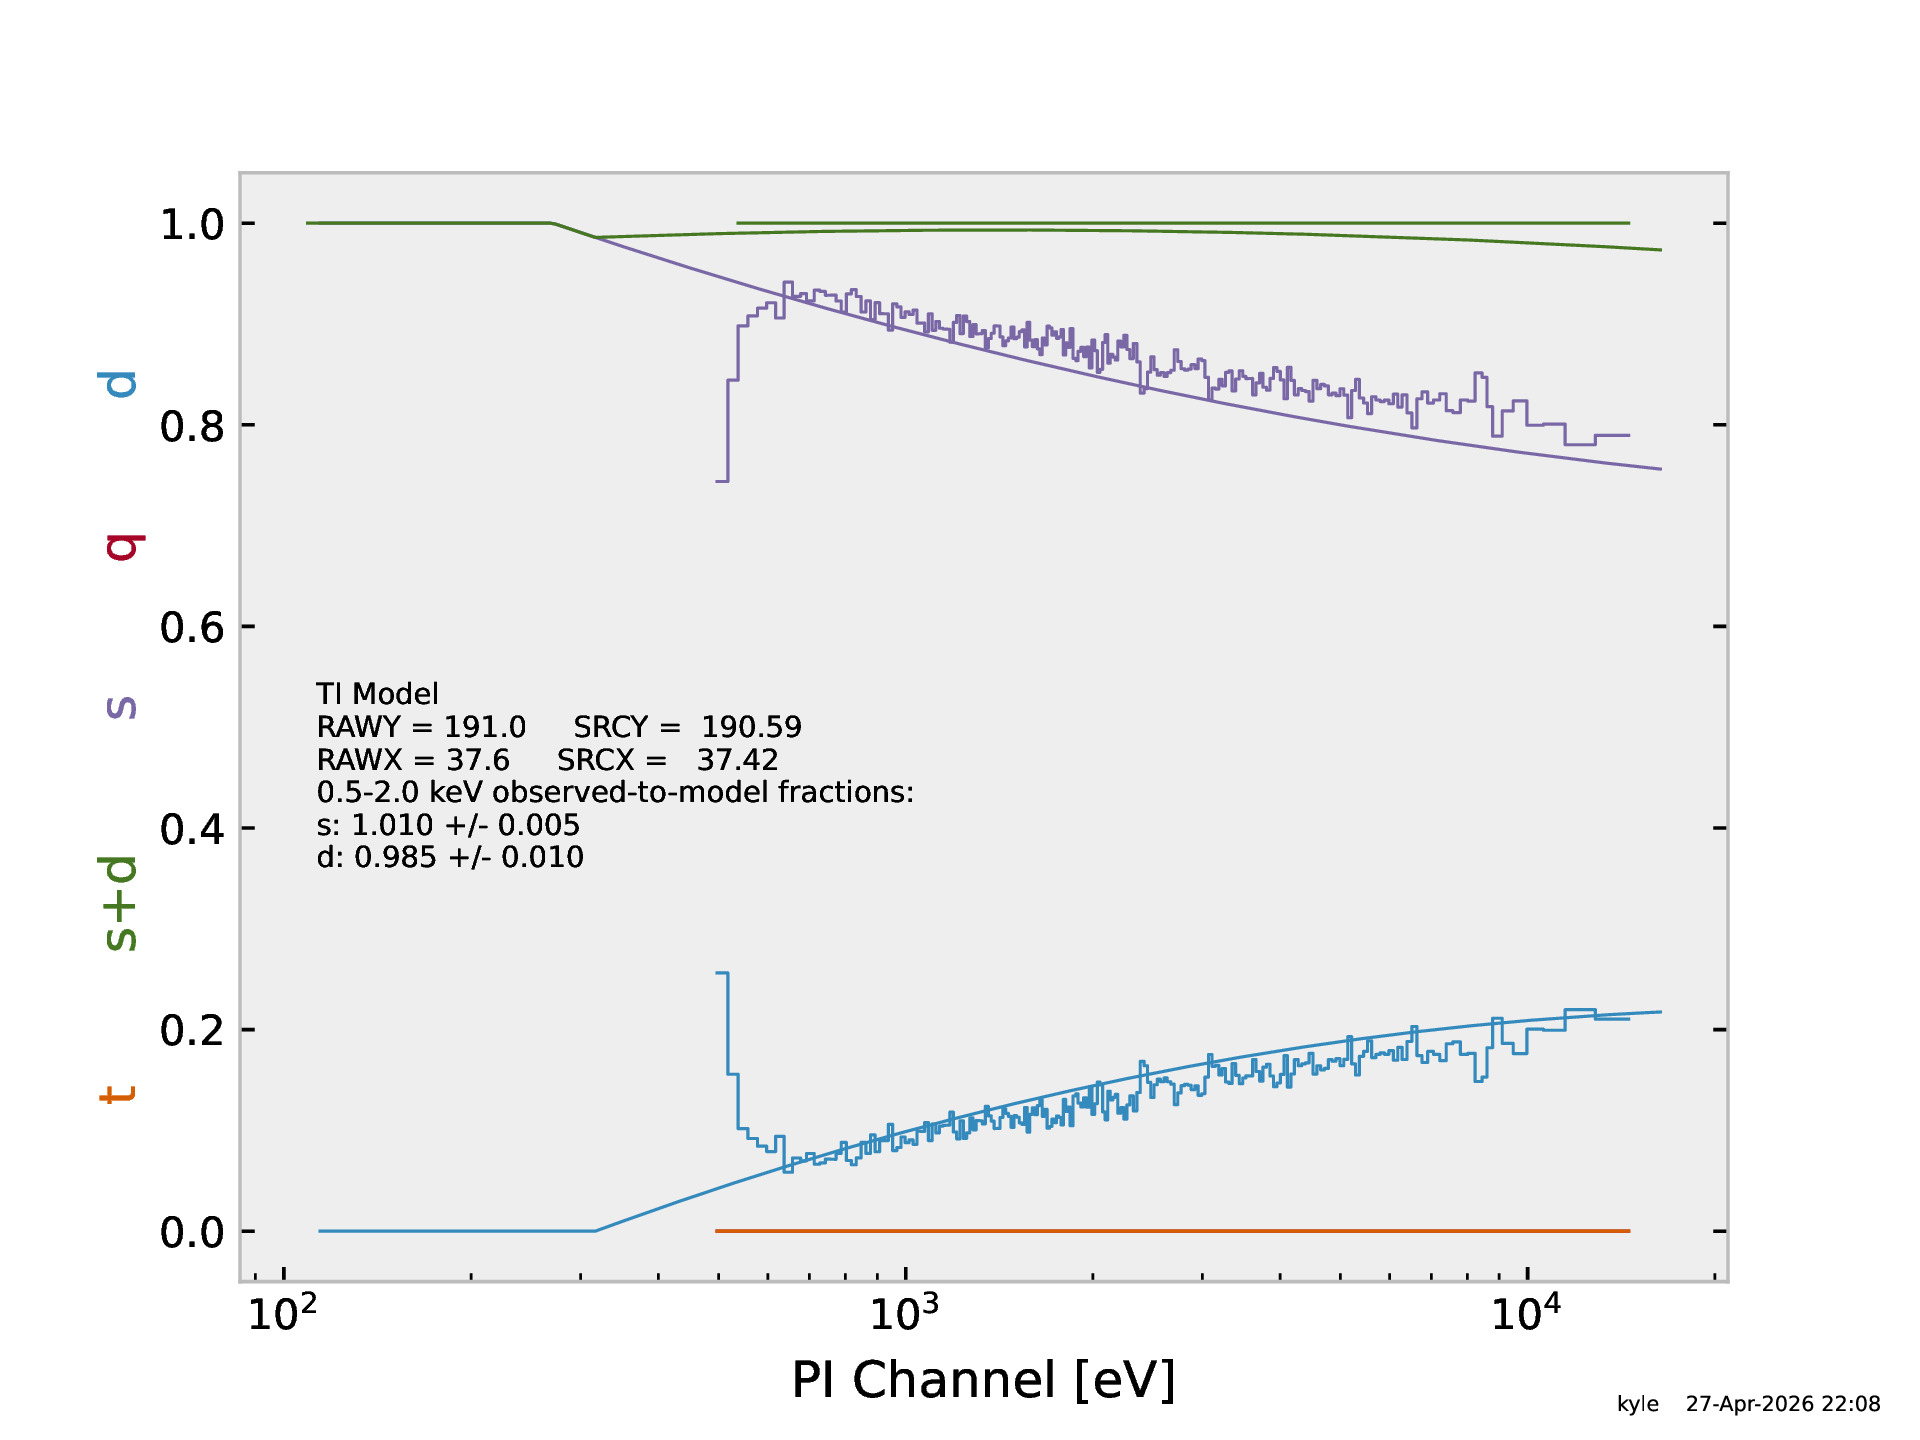

In [6]:
# --- Excised Source Region ---
if os.path.exists(excised_plot_path):
    print(f"EXCISED region epatplot: {excised_plot_path}")
    display(Image(filename=excised_plot_path, width=500))
else:
    print(f"Excised plot not found at {excised_plot_path}")
    print("Set RUN_EXCISION_TEST=\"yes\" in the script and re-run.")

## 3e. Conclusion

The epatplot diagnostics show that pile-up is minimal across the source region. The observed-to-model pattern fractions are consistent with no significant pile-up.

**Confirmed filters for spectral extraction:**

| Region | Filter |
|---|---|
| Source | `(RAWX in [27:47]) && !(RAWX in [36:38])` |
| Background | `RAWX in [1:3]` |

We can now proceed to extract the spectrum (Script 04).